In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

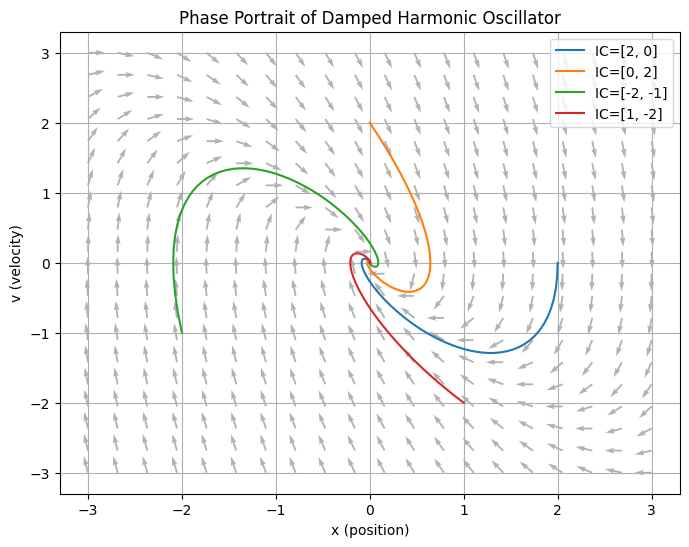

In [ ]:
# Parameters
m = 1.0
c = 2 
k = 2.0

# System
def damped_oscillator(t, z):
    x, v = z
    dxdt = v
    dvdt = -(c/m)*v - (k/m)*x - x**2
    return [dxdt, dvdt]

# Time settings
t_span = (0, 20)
t_eval = np.linspace(*t_span, 400)

# Grid for phase space
x_vals = np.linspace(-3, 3, 20)
v_vals = np.linspace(-3, 3, 20)
X, V = np.meshgrid(x_vals, v_vals)

# Vector field
U = V
W = -(c/m)*V - (k/m)*X

# Normalize for clean arrows
mag = np.sqrt(U**2 + W**2)
U_norm = U / mag
W_norm = W / mag

# Plot
plt.figure(figsize=(8, 6))

# Vector field
plt.quiver(X, V, U_norm, W_norm, color='gray', alpha=0.6)

# Some trajectories
initial_conditions = [
    [2, 0],
    [0, 2],
    [-2, -1],
    [1, -2]
]

for ic in initial_conditions:
    sol = solve_ivp(damped_oscillator, t_span, ic, t_eval=t_eval)
    plt.plot(sol.y[0], sol.y[1], label=f"IC={ic}")

# Labels
plt.xlabel("x (position)")
plt.ylabel("v (velocity)")
plt.title("Phase Portrait of Damped Harmonic Oscillator")
plt.grid()
plt.legend()

plt.show()